# Poređenje modela — bazni CNN vs. Triplet + KNN

- Poredi dva modela:
  1. **Bazni CNN** — direktna klasifikacija slike u jedno od 24 slova
  2. **Triplet + KNN** — mreža nauči reprezentaciju (embedding) slike, a KNN nad tim reprezentacijama vrši klasifikaciju

In [1]:
import json
import re
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.metrics import confusion_matrix

# Isto mapiranje kao LABEL_TO_LETTER u data_utils.py (bez uvoza torch-a)
EXCLUDED_LABELS = {9, 25}  # J, Z zahtevaju pokret, nisu u skupu podataka
_LETTERS = [chr(ord("A") + i) for i in range(26)]
LABEL_TO_LETTER = {i: _LETTERS[i] for i in range(26) if i not in EXCLUDED_LABELS}

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## Konstante

In [2]:
CNN_DIR = Path("../results/CNN model")
KNN_DIR = Path("../results/KNN model")
TRIPLET_DIR = Path("../results/Triplet model")

OUT_DIR = Path("../results/Poređenje modela")
OUT_DIR.mkdir(exist_ok=True)

SORTED_LABELS = sorted(LABEL_TO_LETTER.keys())
LETTERS = [LABEL_TO_LETTER[l] for l in SORTED_LABELS]

## Učitavanje sačuvanih rezultata

In [7]:
with open(CNN_DIR / "cnn_summary.json") as f:
    cnn_summary = json.load(f)

with open(KNN_DIR / "knn_summary.json") as f:
    knn_summary = json.load(f)

with open(TRIPLET_DIR / "triplet_summary.json") as f:
    triplet_summary = json.load(f)

cnn_report_text = (CNN_DIR / "cnn_classification_report.txt").read_text()
knn_report_text = (KNN_DIR / "knn_classification_report.txt").read_text()

print("CNN summary:")
for key, value in cnn_summary.items():
    print('\t', key, ':', value)
print()
print("KNN summary:")
for key, value in knn_summary.items():
    print('\t', key, ':', value)
print()
print("Triplet summary:")
for key, value in triplet_summary.items():
    print('\t', key, ':', value)

CNN summary:
	 model : baseline_cnn_pytorch
	 test_accuracy : 0.9997211377579476
	 num_train_samples : 23336
	 num_val_samples : 4119
	 num_test_samples : 7172
	 epochs_ran : 12

KNN summary:
	 model : knn_over_triplet_embeddings
	 best_k : 1
	 metric : euclidean
	 embedding_dim : 128
	 val_accuracies_by_k : {'1': 1.0, '3': 1.0, '5': 1.0, '7': 1.0, '9': 1.0, '11': 1.0, '15': 1.0, '21': 1.0, '31': 1.0, '45': 1.0, '61': 1.0}
	 test_accuracy : 1.0
	 test_macro_f1 : 1.0
	 num_train_samples : 23336
	 num_val_samples : 4119
	 num_test_samples : 7172

Triplet summary:
	 model : triplet_embedding_cnn_pytorch
	 embedding_dim : 128
	 margin : 0.2
	 m_per_class : 4
	 triplet_batch_size : 96
	 final_train_loss : 0.06863762293424872
	 final_val_loss : 0.001664548580135618
	 intra_class_distance : 0.24751290678977966
	 inter_class_distance : 1.4208170175552368
	 num_train_samples : 23336
	 num_val_samples : 4119
	 num_test_samples : 7172
	 epochs_ran : 15


## Parsiranje classification report-a

In [8]:
def parse_classification_report(text):
    """Vraća (per_class DataFrame, macro_avg dict) iz teksta classification_report-a."""
    rows = []
    for line in text.splitlines():
        m = re.match(r"^\s*([A-Z])\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)\s*$", line)
        if m:
            letter, precision, recall, f1, support = m.groups()
            rows.append({
                "letter": letter,
                "precision": float(precision),
                "recall": float(recall),
                "f1": float(f1),
                "support": int(support),
            })
    per_class = pd.DataFrame(rows).set_index("letter")

    m = re.search(r"macro avg\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)", text)
    macro_avg = {
        "precision": float(m.group(1)),
        "recall": float(m.group(2)),
        "f1": float(m.group(3)),
        "support": int(m.group(4)),
    }
    return per_class, macro_avg


cnn_per_class, cnn_macro_avg = parse_classification_report(cnn_report_text)
knn_per_class, knn_macro_avg = parse_classification_report(knn_report_text)

print(f"CNN  macro F1: {cnn_macro_avg['f1']:.4f}")
print(f"KNN  macro F1: {knn_macro_avg['f1']:.4f}  (poklapa se sa knn_summary['test_macro_f1']={knn_summary['test_macro_f1']:.4f})")

CNN  macro F1: 1.0000
KNN  macro F1: 1.0000  (poklapa se sa knn_summary['test_macro_f1']=1.0000)


## Tabelarno poređenje metrika

In [9]:
comparison_df = pd.DataFrame([
    {
        "Model": "Bazni CNN",
        "Test accuracy": cnn_summary["test_accuracy"],
        "Macro F1": cnn_macro_avg["f1"],
        "Broj grešaka na test skupu": round(cnn_summary["num_test_samples"] * (1 - cnn_summary["test_accuracy"])),
        "Epoha do konvergencije": cnn_summary["epochs_ran"],
        "Trening primera": cnn_summary["num_train_samples"],
    },
    {
        "Model": "Triplet + KNN",
        "Test accuracy": knn_summary["test_accuracy"],
        "Macro F1": knn_summary["test_macro_f1"],
        "Broj grešaka na test skupu": round(knn_summary["num_test_samples"] * (1 - knn_summary["test_accuracy"])),
        "Epoha do konvergencije": triplet_summary["epochs_ran"],
        "Trening primera": knn_summary["num_train_samples"],
    },
]).set_index("Model")

comparison_df

,Test accuracy,Macro F1,Broj grešaka na test skupu,Epoha do konvergencije,Trening primera
Model,,,,,
Bazni CNN,0.999721,1.0,2,12,23336
Triplet + KNN,1.000000,1.0,0,15,23336


## Grafičko poređenje metrika

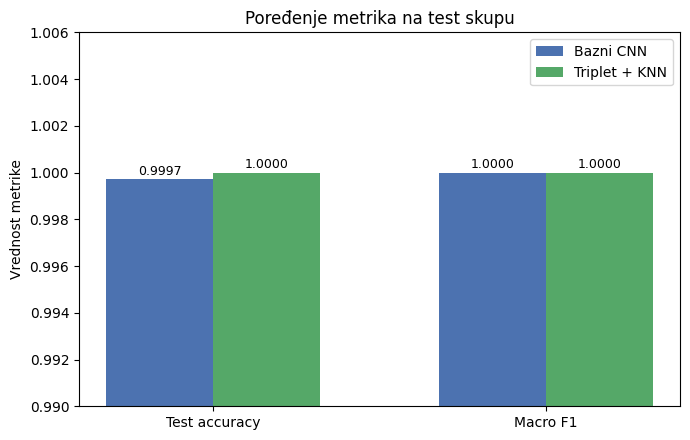

In [10]:
metrics = ["Test accuracy", "Macro F1"]
x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(7, 4.5))
bars_cnn = ax.bar(x - width / 2, comparison_df.loc["Bazni CNN", metrics], width, label="Bazni CNN", color="#4C72B0")
bars_knn = ax.bar(x + width / 2, comparison_df.loc["Triplet + KNN", metrics], width, label="Triplet + KNN", color="#55A868")

for bars in (bars_cnn, bars_knn):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.4f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.99, 1.006)  # oba modela su blizu maksimuma
ax.set_ylabel("Vrednost metrike")
ax.set_title("Poređenje metrika na test skupu")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison_metrics.png", dpi=150)
plt.show()

- Razlika između modela je izuzetno mala (na trećoj/četvrtoj decimali)

- Macro F1 za oba modela ispisuje se kao 1.0000, ali postoje 2 greške od 7172 primera, pa se zaokružuje na 1.000

## Poređenje matrica konfuzije

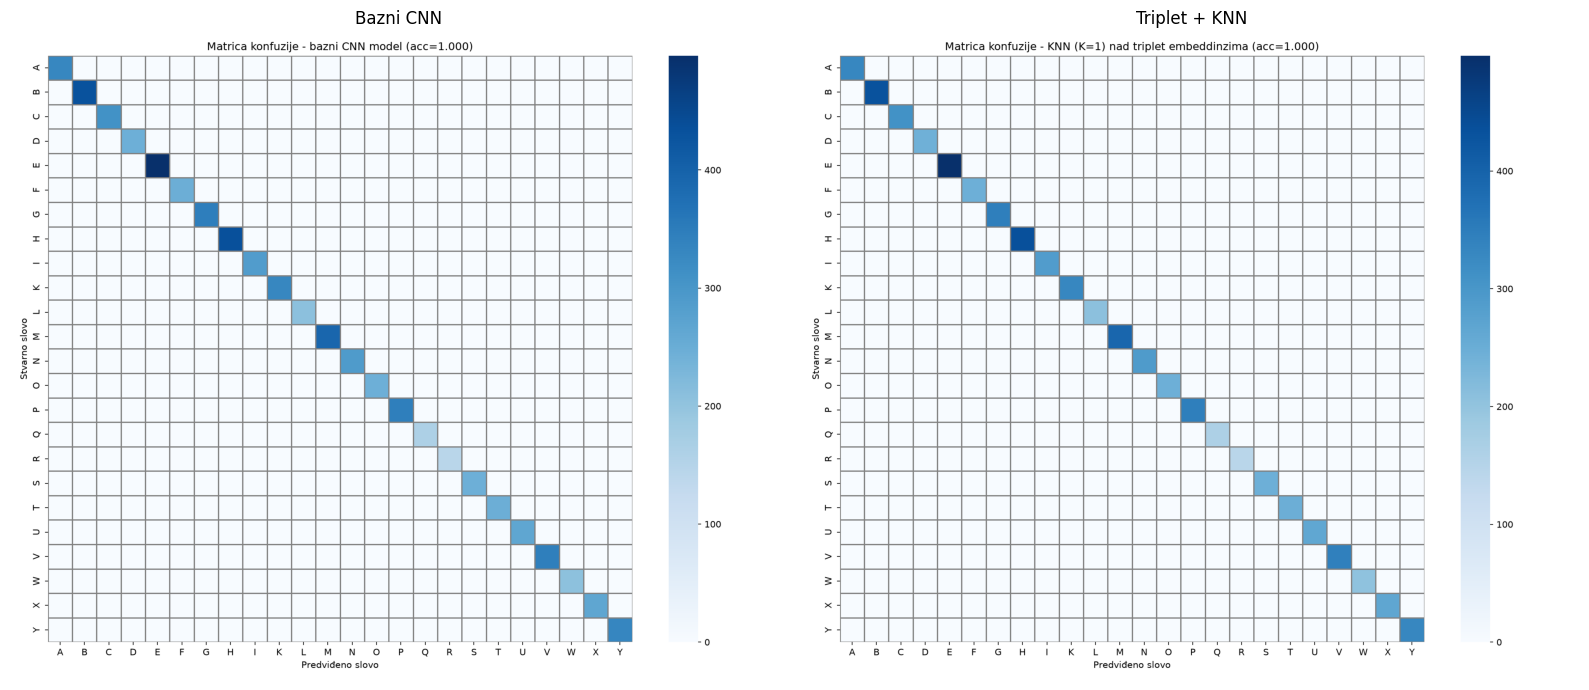

In [11]:
cnn_cm_img = mpimg.imread(CNN_DIR / "cnn_confusion_matrix.png")
knn_cm_img = mpimg.imread(KNN_DIR / "knn_confusion_matrix.png")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(cnn_cm_img)
axes[0].set_title("Bazni CNN")
axes[0].axis("off")

axes[1].imshow(knn_cm_img)
axes[1].set_title("Triplet + KNN")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "cnn_vs_knn_confusion_matrices.png", dpi=150)
plt.show()

Na obe matrice je vidljiva gotovo savršena dijagonala — greške su toliko retke (par primera od 7172) da se ne vide kao vidljiva odstupanja na ovoj rezoluciji.

Zato se u nastavku greške analiziraju numerički, a ne vizuelno.

## Analiza grešaka — koja slova se mešaju i zašto

### Triplet + KNN 

In [12]:
knn_model = joblib.load(KNN_DIR / "knn_classifier.pkl")
embeddings_data = np.load(TRIPLET_DIR / "embeddings.npz")

test_embeddings = embeddings_data["test_embeddings"]
test_labels_knn = embeddings_data["test_labels"]

knn_test_preds = knn_model.predict(test_embeddings)
knn_cm = confusion_matrix(test_labels_knn, knn_test_preds, labels=SORTED_LABELS)

knn_errors = np.argwhere(knn_cm - np.diag(np.diag(knn_cm)))
print(f"Broj grešaka KNN modela na test skupu: {len(knn_errors)}")
if len(knn_errors) == 0:
    print("KNN model nije napravio nijednu grešku na test skupu (matrica konfuzije je čisto dijagonalna).")
else:
    for true_idx, pred_idx in knn_errors:
        print(f"  stvarno {LABEL_TO_LETTER[SORTED_LABELS[true_idx]]} -> predviđeno {LABEL_TO_LETTER[SORTED_LABELS[pred_idx]]}: {knn_cm[true_idx, pred_idx]} put(a)")

C:\Users\Ana\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Broj grešaka KNN modela na test skupu: 0
KNN model nije napravio nijednu grešku na test skupu (matrica konfuzije je čisto dijagonalna).


### Bazni CNN 

- za svako slovo sa `recall < 1` postoji `support * (1 - recall)` promašenih primera tog slova (lažno negativnih),
- za svako slovo sa `precision < 1` postoji višak predikcija za to slovo koje u stvari pripadaju nekom drugom slovu (lažno pozitivnih).

In [13]:
total_cnn_errors = round(cnn_summary["num_test_samples"] * (1 - cnn_summary["test_accuracy"]))
print(f"Ukupan broj grešaka CNN modela na test skupu: {total_cnn_errors}")

fn_candidates = {}
for letter, row in cnn_per_class.iterrows():
    if row["recall"] < 1.0:
        fn = round(row["support"] * (1 - row["recall"]))
        if fn > 0:
            fn_candidates[letter] = fn

fp_candidates = {}
for letter, row in cnn_per_class.iterrows():
    if row["precision"] < 1.0:
        tp = row["support"] * row["recall"]
        predicted_count = tp / row["precision"]
        fp = round(predicted_count - tp)
        if fp > 0:
            fp_candidates[letter] = fp

print(f"Slova sa promašenim primerima (lažno negativni): {fn_candidates}")
print(f"Slova sa viškom predikcija (lažno pozitivni):     {fp_candidates}")

Ukupan broj grešaka CNN modela na test skupu: 2
Slova sa promašenim primerima (lažno negativni): {'B': 1, 'E': 1}
Slova sa viškom predikcija (lažno pozitivni):     {'K': 1, 'S': 1}


Report pokazuje tačno dva slova sa manjkom (lažno negativnih) primera i tačno dva slova sa viškom (lažno pozitivnih) predikcija.

Agregirane metrike same po sebi ne otkrivaju koji konkretan par ide uz koji (npr. da li je greška bila B→K ili B→S), ali se to može proceniti iz prikazane analize podataka.

E i S pripadaju istoj EDA grupi (oba su varijante stisnute pesnice), pa je najverovatnije da je do greške došlo baš u tom paru: **E pogrešno prepoznato kao S**.

Druga greška **B pogrešno prepoznato kao K** — par koji EDA analiza nije predvidela kao vizuelno sličan, pa je verovatnije da je posledica pojedinačnog artefakta (ugao/osvetljenje te jedne slike) nego sistematske sličnosti gesta.

**Triplet + KNN model nije napravio nijednu grešku** na test skupu.

In [14]:
intra = triplet_summary["intra_class_distance"]
inter = triplet_summary["inter_class_distance"]
print(f"Prosečno rastojanje ISTO slovo (intra-class):      {intra:.4f}")
print(f"Prosečno rastojanje RAZLIČITO slovo (inter-class):  {inter:.4f}")
print(f"Odnos intra/inter (manje je bolje):                 {intra / inter:.4f}")

Prosečno rastojanje ISTO slovo (intra-class):      0.2475
Prosečno rastojanje RAZLIČITO slovo (inter-class):  1.4208
Odnos intra/inter (manje je bolje):                 0.1742


Odnos intra/inter rastojanja je znatno manji od 1, što znači da je mreža naučila da razdvoji slova u prostoru reprezentacija mnogo jasnije nego što bi to bio slučaj sa sirovim pikselima.

Kada su klase dobro razdvojene, i jednostavan KNN sa K=1 dovoljan je da postigne savršenu tačnost.

## Prednosti i mane metric learning (triplet + KNN) pristupa u odnosu na CNN

| | Bazni CNN | Triplet + KNN |
|---|---|---|
| **Dodavanje nove klase** | Zahteva ponovno treniranje cele mreže (nova izlazna dimenzija) | Dovoljno je izračunati embedinge za nove primere i dodati ih u skup nad kojim KNN traži susede |
| **Trošak predikcije** | Konstantan (jedan forward prolaz), ne zavisi od veličine trening skupa | Raste sa veličinom trening skupa |
| **Memorijski otisak modela** | Samo težine mreže | Težine mreže za embedinge + kompletan skup trening embedinga |
| **Interpretabilnost grešaka** | Samo krajnja predikcija | Može se pogledati i koji trening primeri su najbliži susedi |
| **Složenost treniranja** | Jedan cross-entropy trening | Dodatna faza (izbor margine, mining strategije, MPerClassSampler) |
| **Few-shot scenario** | Nepraktično bez ponovnog treniranja | Prirodno podržano |

Najveća prednost metric learning pristupa u ovom projektu nije tačnost, već **fleksibilnost**: kada bi se skup gestova proširio (npr. dodala slova J/Z uz pokret, ili čitave reči), CNN bi morao da se retrenira od nule sa novom klasifikacionom glavom, dok bi triplet mreži bilo dovoljno da izračuna embedinge za nove primere.

## Čuvanje rezultata poređenja

In [15]:
comparison_summary = {
    "cnn": {
        "test_accuracy": cnn_summary["test_accuracy"],
        "macro_f1": cnn_macro_avg["f1"],
        "num_errors_test": int(total_cnn_errors),
        "fn_candidates": fn_candidates,
        "fp_candidates": fp_candidates,
    },
    "knn_over_triplet": {
        "test_accuracy": knn_summary["test_accuracy"],
        "macro_f1": knn_summary["test_macro_f1"],
        "num_errors_test": int(len(knn_errors)),
    },
    "triplet_intra_inter_ratio": intra / inter,
}

with open(OUT_DIR / "poredjenje_summary.json", "w") as f:
    json.dump(comparison_summary, f, indent=2, ensure_ascii=False)

comparison_summary

{'cnn': {'test_accuracy': 0.9997211377579476,
  'macro_f1': 1.0,
  'num_errors_test': 2,
  'fn_candidates': {'B': 1, 'E': 1},
  'fp_candidates': {'K': 1, 'S': 1}},
 'knn_over_triplet': {'test_accuracy': 1.0,
  'macro_f1': 1.0,
  'num_errors_test': 0},
 'triplet_intra_inter_ratio': 0.17420463277929255}